# LRA fragmentation diagnostics — contigs, completeness, level, hybrids, `is_complete`

Follow-up to [`lra_quality_cutoffs.ipynb`](lra_quality_cutoffs.ipynb), which
locked the LRA acceptance rule (≥99 % completeness, ≤5 % contamination,
genome size ≤ worst-GCF). Colleagues asked five questions that don't fit there:

1. **Fragmentation** — many GCAs sit in a second contig-count peak (50–150
   contigs). Quantify it.
2. **"Complete to 99 %" calibration** — what do CheckM2 completeness
   distributions look like for short-read assemblies, GCAs and GCFs?
3. **NCBI `assembly_level`** — counts by tier, and any systematic tie to
   contig count / N50 / completeness?
4. **Hybrid (short + long) assemblies** — how many of our reference-tier
   genomes are hybrids by submitter-reported sequencing tech?
5. **`is_complete` flag** — if we add this flag (level == `Complete Genome`) to
   the LRA metadata, what's its coverage, hybrid overlap, and intersection
   with the 2,920 paired SR↔LRA index?

No new acceptance rule is being locked here — this notebook reports.


## 1 · Load the three caches

- `lra_discovery.tsv` — drives §2–§4 (required).
- `sr_checkm2.tsv` — short-read CheckM2 from Aaron's QC workbook (required for §3).
- `lra_ncbi_assembly_meta.tsv` — submitter platform / NCBI level (required for §5;
  §4 has an optional sanity-check that uses it).

If the NCBI cache isn't on disk yet, §5 cells short-circuit gracefully so the
notebook still runs.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("_data")

# LRA discovery — one row per biological assembly, with CheckM2 + level
disc = pd.read_csv(DATA / "lra_discovery.tsv", sep="\t", low_memory=False)
disc["tier"] = np.where(
    disc["scoring_accession"].str.startswith("GCF_"),
    "GCF",
    np.where(disc["scoring_accession"].str.startswith("GCA_"), "GCA", "Other"),
)
print(
    f"LRA rows: {len(disc):,}   "
    f"GCF={(disc.tier=='GCF').sum():,}   "
    f"GCA={(disc.tier=='GCA').sum():,}"
)


LRA rows: 5,557   GCF=4,363   GCA=1,194


In [2]:
# Short-read CheckM2 — normalise column names to lowercase
sr = pd.read_csv(DATA / "sr_checkm2.tsv", sep="\t", low_memory=False)
sr = sr.rename(columns={
    "Sample": "sample",
    "Completeness": "completeness",
    "Contamination": "contamination",
    "Contig_N50": "contig_n50",
    "Total_Contigs": "total_contigs",
    "Genome_Size": "genome_size",
})
print(f"Short-read CheckM2 rows: {len(sr):,}")
sr.head(3)


Short-read CheckM2 rows: 97,166


,sample,completeness,contamination,contig_n50,genome_size,total_contigs
0,SAMN37974148,100.0,0.24,220391,5221778,84
1,SAMN37984267,100.0,0.09,355855,5425025,107
2,SAMN37999686,100.0,1.15,256218,5700220,114


In [3]:
# Optional NCBI assembly metadata cache
NCBI_META_PATH = DATA / "lra_ncbi_assembly_meta.tsv"
has_ncbi_meta = NCBI_META_PATH.exists()
if has_ncbi_meta:
    nm = pd.read_csv(NCBI_META_PATH, sep="\t", low_memory=False)
    disc["_lookup"] = disc["scoring_accession"].astype(str).str.split(".").str[0]
    disc = disc.merge(
        nm.rename(columns={"lookup_accession": "_lookup"}),
        on="_lookup",
        how="left",
    ).drop(columns=["_lookup"])
    print(f"NCBI assembly meta: {len(nm):,} rows merged onto LRA discovery")
    print(f"  matched rows in disc: {disc['ncbi_assembly_level'].notna().sum():,}")
else:
    print(f"NCBI cache not present — §5 will short-circuit.")
    print(f"  Expected path: {NCBI_META_PATH.resolve()}")


NCBI assembly meta: 5,556 rows merged onto LRA discovery
  matched rows in disc: 5,556


## 2 · Q1 — contig-count fragmentation

Histogram of `checkm2_total_contigs` for GCF vs GCA. Two peaks are visible:
one around ≤15 contigs (the well-assembled bulk) and a second around 50–150
contigs (the fragmented tail, mostly GCA). Dashed grey lines mark 15 and 40
to flag those boundaries.


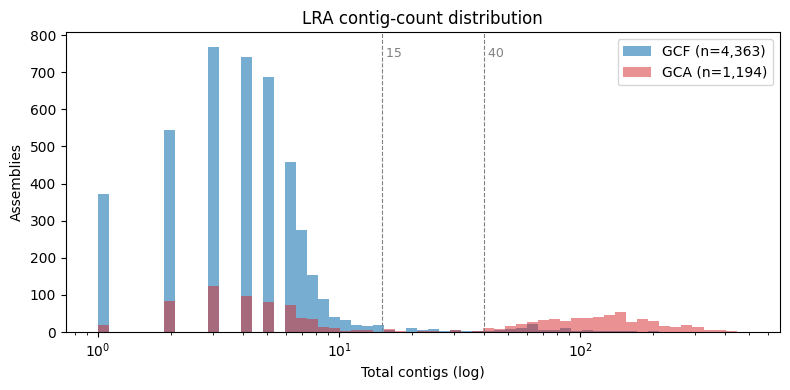

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
max_c = int(disc["checkm2_total_contigs"].max())
bins = np.logspace(0, np.log10(max_c), 60)

gcf = disc.loc[disc.tier == "GCF", "checkm2_total_contigs"].dropna()
gca = disc.loc[disc.tier == "GCA", "checkm2_total_contigs"].dropna()

ax.hist(gcf, bins=bins, color="C0", alpha=0.6, label=f"GCF (n={len(gcf):,})")
ax.hist(gca, bins=bins, color="C3", alpha=0.5, label=f"GCA (n={len(gca):,})")
for x in (15, 40):
    ax.axvline(x, ls="--", color="grey", lw=0.8)
    ax.text(x, ax.get_ylim()[1] * 0.95, f" {x}", color="grey", va="top", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Total contigs (log)")
ax.set_ylabel("Assemblies")
ax.set_title("LRA contig-count distribution")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# Quantify the two-peak structure
rows = []
for tier, sub in disc.groupby("tier"):
    tc = sub["checkm2_total_contigs"].dropna()
    rows.append({
        "tier": tier,
        "n": len(tc),
        "median_contigs": float(tc.median()),
        ">15 contigs": int((tc > 15).sum()),
        ">15 contigs %": round(100 * (tc > 15).mean(), 1),
        ">40 contigs": int((tc > 40).sum()),
        ">40 contigs %": round(100 * (tc > 40).mean(), 1),
    })
pd.DataFrame(rows)


,tier,n,median_contigs,>15 contigs,>15 contigs %,>40 contigs,>40 contigs %
0,GCA,1194,16.5,602,50.4,572,47.9
1,GCF,4363,4.0,143,3.3,99,2.3


## 3 · Q2 — short-read vs LRA completeness calibration

The ≥99 % completeness cutoff was set from the GCF empirical distribution.
The question raised: how does the short-read CheckM2 distribution compare?
If SR is comparably high, the floor isn't pulling its weight as a quality
filter.

SR has ~14× more genomes than LRA, so SR is plotted on a secondary y-axis.


In [6]:
def three_way_hist(disc_col, sr_col, bins, *, title, xlabel, xlim=None):
    """Overlaid histogram: GCF + GCA on primary axis, SR on twin secondary."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax_sr = ax.twinx()

    gcf = disc.loc[disc.tier == "GCF", disc_col].dropna()
    gca = disc.loc[disc.tier == "GCA", disc_col].dropna()
    sr_v = sr[sr_col].dropna()

    ax.hist(gcf, bins=bins, color="C0", alpha=0.6, label=f"GCF (n={len(gcf):,})")
    ax.hist(gca, bins=bins, color="C3", alpha=0.5, label=f"GCA (n={len(gca):,})")
    ax_sr.hist(sr_v, bins=bins, color="gold", alpha=0.4, label=f"SR (n={len(sr_v):,})")

    if xlim:
        ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("LRA assemblies (GCF/GCA)")
    ax_sr.set_ylabel("Short-read assemblies (secondary)", color="goldenrod")
    ax.set_title(title)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_sr.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left")
    plt.tight_layout()
    plt.show()


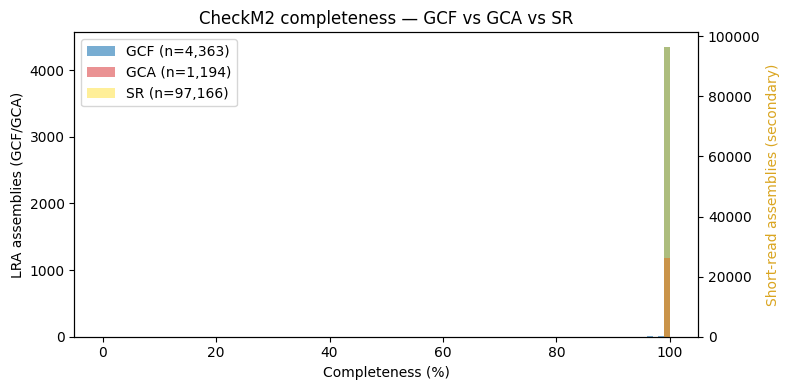

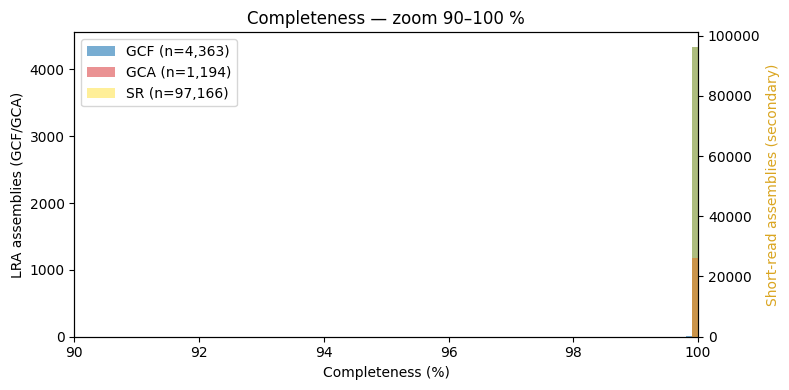

In [7]:
# Completeness — full range and zoomed 90–100 %
three_way_hist(
    "checkm2_completeness", "completeness",
    bins=np.linspace(0, 100, 101),
    title="CheckM2 completeness — GCF vs GCA vs SR",
    xlabel="Completeness (%)",
)
three_way_hist(
    "checkm2_completeness", "completeness",
    bins=np.linspace(90, 100, 101),
    title="Completeness — zoom 90–100 %",
    xlabel="Completeness (%)", xlim=(90, 100),
)


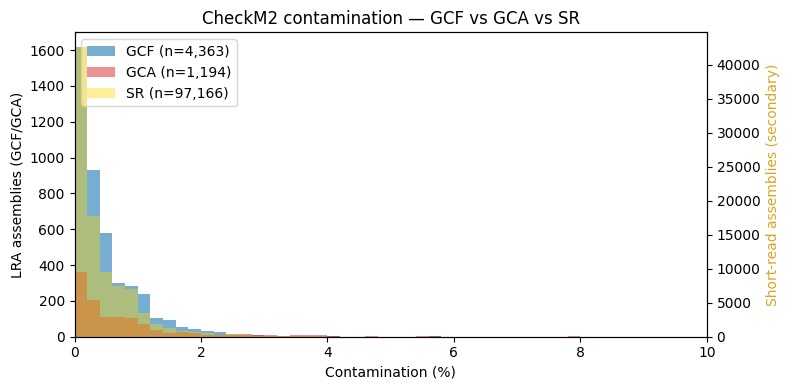

In [8]:
# Contamination — zoom 0–10 %
three_way_hist(
    "checkm2_contamination", "contamination",
    bins=np.linspace(0, 10, 51),
    title="CheckM2 contamination — GCF vs GCA vs SR",
    xlabel="Contamination (%)", xlim=(0, 10),
)


In [9]:
# Headline: fraction of each cohort sitting above 99 % completeness
def _share(s, thresh):
    s = s.dropna()
    return f"{(s >= thresh).sum():>6,} / {len(s):,}  ({100*(s>=thresh).mean():.1f}%)"

print("Fraction with completeness ≥ 99 %:")
print(f"  GCF: {_share(disc.loc[disc.tier=='GCF','checkm2_completeness'], 99)}")
print(f"  GCA: {_share(disc.loc[disc.tier=='GCA','checkm2_completeness'], 99)}")
print(f"  SR : {_share(sr['completeness'], 99)}")


Fraction with completeness ≥ 99 %:
  GCF:  4,349 / 4,363  (99.7%)
  GCA:  1,184 / 1,194  (99.2%)
  SR : 96,483 / 97,166  (99.3%)


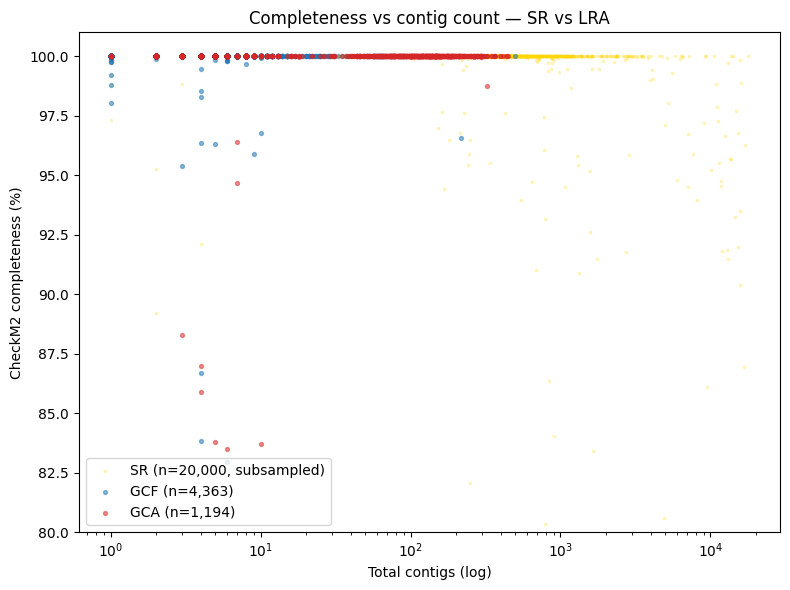

In [10]:
# Scatter — completeness vs contig count, three cohorts overlaid
fig, ax = plt.subplots(figsize=(8, 6))
sr_sample = sr.dropna(subset=["completeness", "total_contigs"])
# subsample SR if it's enormous — keep it visually meaningful
if len(sr_sample) > 20_000:
    sr_sample = sr_sample.sample(20_000, random_state=0)

ax.scatter(sr_sample["total_contigs"], sr_sample["completeness"],
           s=3, color="gold", alpha=0.2, label=f"SR (n={len(sr_sample):,}, subsampled)")
for tier, color in [("GCF", "C0"), ("GCA", "C3")]:
    sub = disc[disc.tier == tier].dropna(subset=["checkm2_completeness", "checkm2_total_contigs"])
    ax.scatter(sub["checkm2_total_contigs"], sub["checkm2_completeness"],
               s=8, color=color, alpha=0.5, label=f"{tier} (n={len(sub):,})")
ax.set_xscale("log")
ax.set_ylim(80, 101)
ax.set_xlabel("Total contigs (log)")
ax.set_ylabel("CheckM2 completeness (%)")
ax.set_title("Completeness vs contig count — SR vs LRA")
ax.legend()
plt.tight_layout()
plt.show()


## 4 · Q3 — NCBI `assembly_level` label

Four labels: `Contig`, `Scaffold`, `Chromosome`, `Complete Genome`. Are they
distributed differently across GCF / GCA? Are they driven by contig count
(i.e. essentially a re-labelling of fragmentation), or by something else?

`level` already lives in `lra_discovery.tsv`; the NCBI cache (if loaded)
provides a sanity check at the end of this section.


In [11]:
LEVELS = ["Contig", "Scaffold", "Chromosome", "Complete Genome"]

# `level` from lra_discovery.tsv is only populated for ~2,500 rows (the is_refseq
# metadata source didn't carry it); `ncbi_assembly_level` from the cache is
# populated for all 5,556 resolved accessions. Prefer the cache when present.
if has_ncbi_meta and "ncbi_assembly_level" in disc.columns:
    LEVEL_COL = "ncbi_assembly_level"
    print("Using `ncbi_assembly_level` (NCBI cache) as canonical level.")
else:
    LEVEL_COL = "level"
    print("Using `level` from lra_discovery.tsv (NCBI cache not loaded).")

disc["_lvl"] = pd.Categorical(disc[LEVEL_COL], categories=LEVELS, ordered=True)

tbl = (
    disc.groupby(["_lvl", "tier"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(LEVELS)
)
print(f"\nCounts of {LEVEL_COL} × tier:")
print(tbl)
n_missing = disc["_lvl"].isna().sum()
print(f"\nTotals  GCF={tbl.get('GCF', pd.Series()).sum():,}  "
      f"GCA={tbl.get('GCA', pd.Series()).sum():,}  "
      f"(unresolved/blank: {n_missing:,})")


Using `ncbi_assembly_level` (NCBI cache) as canonical level.

Counts of ncbi_assembly_level × tier:
tier             GCA   GCF
_lvl                      
Contig           804   425
Scaffold           5    45
Chromosome        11   240
Complete Genome  374  3652

Totals  GCF=4,362  GCA=1,194  (unresolved/blank: 1)


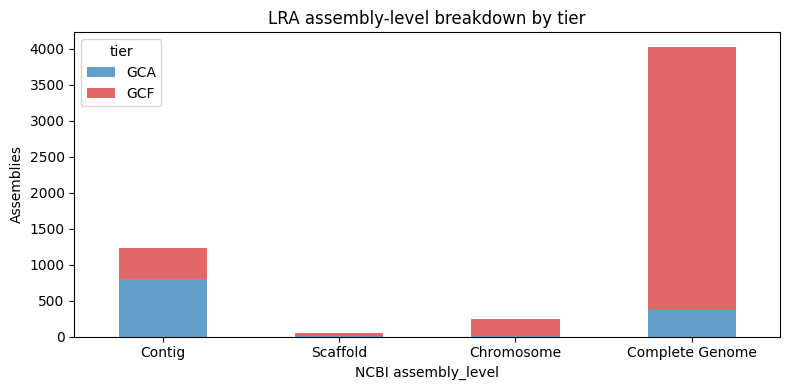

In [12]:
# Stacked bar
fig, ax = plt.subplots(figsize=(8, 4))
tbl.plot(kind="bar", stacked=True, color=["C0", "C3"], ax=ax, alpha=0.7)
ax.set_ylabel("Assemblies")
ax.set_xlabel("NCBI assembly_level")
ax.set_title("LRA assembly-level breakdown by tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


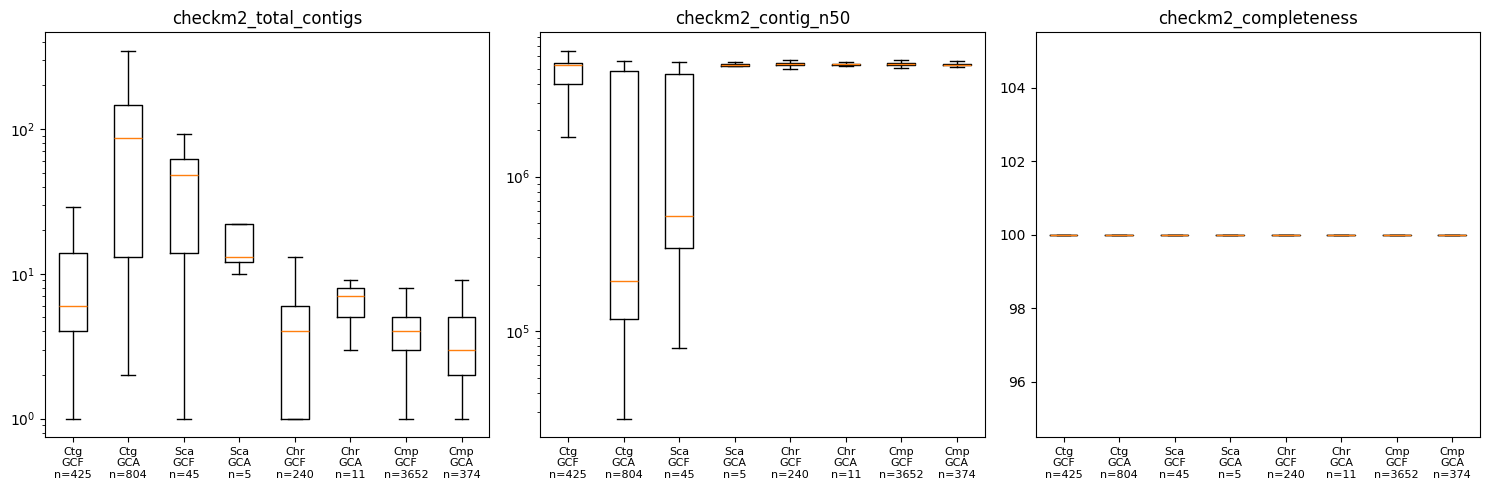

In [13]:
# Boxplots of fragmentation / quality by level × tier
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, ylog in [
    (axes[0], "checkm2_total_contigs", True),
    (axes[1], "checkm2_contig_n50", True),
    (axes[2], "checkm2_completeness", False),
]:
    pivot, labels = [], []
    for lev in LEVELS:
        for tier, _ in [("GCF", "C0"), ("GCA", "C3")]:
            vals = disc.loc[(disc._lvl == lev) & (disc.tier == tier), metric].dropna()
            if len(vals):
                pivot.append(vals)
                short_lev = {"Contig": "Ctg", "Scaffold": "Sca", "Chromosome": "Chr", "Complete Genome": "Cmp"}[lev]
                labels.append(f"{short_lev}\n{tier}\nn={len(vals)}")
    bp = ax.boxplot(pivot, tick_labels=labels, showfliers=False)
    if ylog:
        ax.set_yscale("log")
    ax.set_title(metric)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()


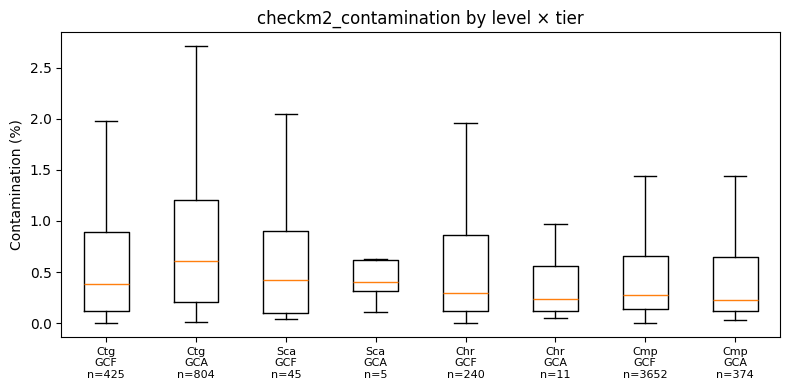

In [14]:
# Contamination by level (separate plot — different y-scale)
fig, ax = plt.subplots(figsize=(8, 4))
pivot, labels = [], []
for lev in LEVELS:
    for tier in ("GCF", "GCA"):
        vals = disc.loc[(disc._lvl == lev) & (disc.tier == tier), "checkm2_contamination"].dropna()
        if len(vals):
            pivot.append(vals)
            short_lev = {"Contig": "Ctg", "Scaffold": "Sca", "Chromosome": "Chr", "Complete Genome": "Cmp"}[lev]
            labels.append(f"{short_lev}\n{tier}\nn={len(vals)}")
ax.boxplot(pivot, tick_labels=labels, showfliers=False)
ax.set_ylabel("Contamination (%)")
ax.set_title("checkm2_contamination by level × tier")
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()


In [15]:
# Median contigs by level × tier — answers "is the label just a contig-count label?"
print("Median `checkm2_total_contigs` by level × tier:")
print(
    disc.groupby(["tier", "_lvl"], observed=True)["checkm2_total_contigs"]
    .median()
    .unstack()
    .reindex(["GCF", "GCA"])
)


Median `checkm2_total_contigs` by level × tier:
_lvl  Contig  Scaffold  Chromosome  Complete Genome
tier                                               
GCF      6.0      48.0         4.0              4.0
GCA     87.0      13.0         7.0              3.0


In [16]:
# Sanity-check (guarded): does the NCBI cache agree with `level` in lra_discovery.tsv?
if has_ncbi_meta and "ncbi_assembly_level" in disc.columns:
    a, b = disc["level"], disc["ncbi_assembly_level"]
    both = a.notna() & b.notna()
    only_ncbi = a.isna() & b.notna()
    only_disc = a.notna() & b.isna()
    neither = a.isna() & b.isna()
    print(f"Coverage: both populated = {both.sum():,}  |  only NCBI = {only_ncbi.sum():,}  |  "
          f"only lra_discovery = {only_disc.sum():,}  |  neither = {neither.sum():,}")
    mism = both & (a.astype(str) != b.astype(str))
    print(f"\nDisagreements where both populated: {mism.sum()} of {both.sum()}")
    if mism.sum():
        print("Examples:")
        print(disc.loc[mism, ["scoring_accession", "level", "ncbi_assembly_level"]].head())
else:
    print("(NCBI cache not loaded — skipping sanity check.)")


Coverage: both populated = 2,571  |  only NCBI = 2,985  |  only lra_discovery = 0  |  neither = 1

Disagreements where both populated: 0 of 2571


## 5 · Q4 — hybrid (short + long) assemblies

Submitter-reported `ncbi_sequencing_tech` is free text — e.g.
`"Illumina; PacBio"`, `"Oxford Nanopore MinION"`. Classify into:

- **hybrid** — at least one long-read term *and* at least one short-read term
- **long_only** — long-read term only
- **short_only** — short-read term only
- **unknown** — blank / unparseable

This whole section needs the NCBI cache; cells short-circuit if it isn't loaded.


In [17]:
LONG_RE = re.compile(r"pacbio|nanopore|\bont\b|oxford|smrt|hifi", re.I)
SHORT_RE = re.compile(r"illumina|hiseq|miseq|nextseq|novaseq|bgi|mgi|dnbseq|bgiseq|solid|ion[\s_-]?torrent", re.I)


def classify_tech(tech):
    """Map raw ncbi_sequencing_tech string to library class."""
    if pd.isna(tech) or not str(tech).strip():
        return "unknown"
    s = str(tech)
    has_long = bool(LONG_RE.search(s))
    has_short = bool(SHORT_RE.search(s))
    if has_long and has_short:
        return "hybrid"
    if has_long:
        return "long_only"
    if has_short:
        return "short_only"
    return "unknown"


if has_ncbi_meta and "ncbi_sequencing_tech" in disc.columns:
    disc["library_class"] = disc["ncbi_sequencing_tech"].apply(classify_tech)
    print("Library class × tier (all 5,557 LRA candidates):")
    print(pd.crosstab(disc["library_class"], disc["tier"], margins=True))
else:
    print("(NCBI cache not loaded — §5 skipped.)")


Library class × tier (all 5,557 LRA candidates):
tier            GCA   GCF   All
library_class                  
hybrid          570  2059  2629
long_only        30  1651  1681
short_only      578   462  1040
unknown          16   191   207
All            1194  4363  5557


In [18]:
# Same breakdown restricted to the accepted-LRA subset (the lra_quality_cutoffs §8 gate)
if has_ncbi_meta and "library_class" in disc.columns:
    gcf_size_cap = disc.loc[disc.tier == "GCF", "checkm2_genome_size"].max()
    accepted = disc[
        (disc["checkm2_completeness"] >= 99)
        & (disc["checkm2_contamination"] <= 5)
        & (disc["checkm2_genome_size"] <= gcf_size_cap)
    ]
    print(f"Worst-GCF genome-size cap: {int(gcf_size_cap):,} bp")
    print(f"Accepted subset: {len(accepted):,} of {len(disc):,}\n")
    print("Library class × tier (ACCEPTED LRA subset only):")
    print(pd.crosstab(accepted["library_class"], accepted["tier"], margins=True))


Worst-GCF genome-size cap: 7,227,285 bp
Accepted subset: 5,521 of 5,557

Library class × tier (ACCEPTED LRA subset only):
tier            GCA   GCF   All
library_class                  
hybrid          561  2057  2618
long_only        29  1639  1668
short_only      574   460  1034
unknown          11   190   201
All            1175  4346  5521


In [19]:
# Unknown bucket — top 20 raw strings, so we can grow the regex if needed
if has_ncbi_meta and "library_class" in disc.columns:
    unk = disc.loc[disc["library_class"] == "unknown", "ncbi_sequencing_tech"]
    print(f"Unknown bucket: {len(unk):,} rows  ({unk.isna().sum():,} NaN/blank)")
    print("\nTop 20 raw ncbi_sequencing_tech values in 'unknown':")
    print(unk.fillna("(NaN/blank)").astype(str).value_counts().head(20).to_string())


Unknown bucket: 207 rows  (13 NaN/blank)

Top 20 raw ncbi_sequencing_tech values in 'unknown':
ncbi_sequencing_tech
MinION                       84
SLX                          40
GridION                      19
Complete Genomics            17
(NaN/blank)                  13
RS-II                         6
Pacific Biosciences RS II     6
MicrobesNG                    5
QPursue-6k                    3
Truseq SBS Kit                2
Hybrid                        2
Pacific Biosciences           2
Sanger                        1
CANU                          1
PromethION                    1
50X                           1
nanopre                       1
SLX, MinION                   1
Pacific Biosciences RSII      1
Minion                        1


In [20]:
# Cross-tab: library_class × ncbi_assembly_level — do hybrids cluster in Complete Genome / Chromosome?
if has_ncbi_meta and "library_class" in disc.columns and "ncbi_assembly_level" in disc.columns:
    print("library_class × ncbi_assembly_level:")
    print(pd.crosstab(
        disc["library_class"],
        disc["ncbi_assembly_level"].fillna("(blank)"),
        margins=True,
    ))


library_class × ncbi_assembly_level:
ncbi_assembly_level  (blank)  Chromosome  Complete Genome  Contig  Scaffold  \
library_class                                                                 
hybrid                     0          92             2134     390        13   
long_only                  0          39             1532     110         0   
short_only                 0         112              217     698        13   
unknown                    1           8              143      31        24   
All                        1         251             4026    1229        50   

ncbi_assembly_level   All  
library_class              
hybrid               2629  
long_only            1681  
short_only           1040  
unknown               207  
All                  5557  


In [21]:
# Within accepted-LRA + GCA-only (the riskiest sub-population): how many are hybrids?
if has_ncbi_meta and "library_class" in disc.columns:
    risky = accepted[accepted.tier == "GCA"]
    print(f"Accepted GCAs: {len(risky):,}")
    print("\nlibrary_class breakdown among accepted GCAs:")
    print(risky["library_class"].value_counts().to_string())


Accepted GCAs: 1,175

library_class breakdown among accepted GCAs:
library_class
short_only    574
hybrid        561
long_only      29
unknown        11


## 6 · Q5 — proposed `is_complete` flag

Decision under consideration: add a boolean `is_complete` to the LRA
metadata, defined as `ncbi_assembly_level == "Complete Genome"`.

**Source of truth**: the NCBI Datasets cache built in §1, *not* the `level`
column in `lra_discovery.tsv` (missing for ~3 k is_refseq rows) and *not*
the existing `lra_is_complete` column in `paired_index.tsv` (derived
from the same stale `level` and therefore wrong for those rows — to be
rebuilt downstream).

Three stats requested:

1. How many LRA assemblies would be `is_complete=True`?
2. How many of those are hybrid (per §5)?
3. How many of the 2,920 paired SR↔LRA rows have an `is_complete=True` LRA?


In [22]:
# (1) Define is_complete from the NCBI cache truth
if not has_ncbi_meta:
    raise RuntimeError("§6 requires the NCBI cache — re-run cache_lra_assembly_meta.py first.")

disc["is_complete"] = (disc["ncbi_assembly_level"] == "Complete Genome")

print("(1) `is_complete` coverage in the LRA cohort:")
print(f"  Total LRA: {len(disc):,}")
print(f"  is_complete=True : {disc.is_complete.sum():,}  ({100*disc.is_complete.mean():.1f}%)")
print(f"  is_complete=False: {(~disc.is_complete).sum():,}  ({100*(~disc.is_complete).mean():.1f}%)")

print("\n  By tier:")
print(
    disc.groupby("tier")["is_complete"]
    .agg(["sum", "count"])
    .assign(pct=lambda d: (100 * d["sum"] / d["count"]).round(1))
    .rename(columns={"sum": "is_complete=True", "count": "n"})
)


(1) `is_complete` coverage in the LRA cohort:
  Total LRA: 5,557
  is_complete=True : 4,026  (72.4%)
  is_complete=False: 1,531  (27.6%)

  By tier:
      is_complete=True     n   pct
tier                              
GCA                374  1194  31.3
GCF               3652  4363  83.7


In [23]:
# (2) Hybrid overlap among is_complete=True
if "library_class" not in disc.columns:
    raise RuntimeError("§5 must run first to populate library_class.")

cmp_lib = pd.crosstab(
    disc.loc[disc.is_complete, "library_class"],
    disc.loc[disc.is_complete, "tier"],
    margins=True,
)
print("(2) library_class × tier WITHIN is_complete=True LRA:")
print(cmp_lib)

n_complete = int(disc.is_complete.sum())
n_complete_hybrid = int(((disc.is_complete) & (disc.library_class == "hybrid")).sum())
print(
    f"\n  Headline: {n_complete_hybrid:,} of {n_complete:,} is_complete LRA are hybrid "
    f"({100*n_complete_hybrid/n_complete:.1f}%)"
)


(2) library_class × tier WITHIN is_complete=True LRA:
tier           GCA   GCF   All
library_class                 
hybrid         356  1778  2134
long_only        9  1523  1532
short_only       0   217   217
unknown          9   134   143
All            374  3652  4026

  Headline: 2,134 of 4,026 is_complete LRA are hybrid (53.0%)


In [24]:
# (3) Intersection with paired SR↔LRA index
# paired_index.tsv has 2,920 rows; lra_sample is a versioned GCA/GCF accession.
# We use it only for its lra_sample list — we IGNORE its lra_is_complete /
# lra_assembly_level columns because they were built from the stale `level`
# field and undercount completes.
PAIRED_PATH = DATA / "paired_index.tsv"
if not PAIRED_PATH.exists():
    raise FileNotFoundError(
        f"paired_index.tsv not found at {PAIRED_PATH}. Rsync from HPC: "
        f"<RDS>/david/processed/complete_vs_sr_genomes/paired_index.tsv"
    )

paired = pd.read_csv(PAIRED_PATH, sep="\t", low_memory=False)
print(f"paired_index.tsv rows: {len(paired):,}")

# Strip the version off lra_sample and join to disc via the same lookup key
paired["_lookup"] = paired["lra_sample"].astype(str).str.split(".").str[0]
disc["_lookup"] = disc["scoring_accession"].astype(str).str.split(".").str[0]

joined = paired.merge(
    disc[["_lookup", "tier", "ncbi_assembly_level", "is_complete", "library_class"]]
        .rename(columns={"is_complete": "is_complete_ncbi"}),
    on="_lookup",
    how="left",
)

matched = joined["is_complete_ncbi"].notna().sum()
unmatched = len(joined) - matched
print(f"  matched against LRA discovery: {matched:,}  unmatched: {unmatched}")

n_paired_complete = int(joined["is_complete_ncbi"].fillna(False).sum())
print(
    f"\n  Of {len(joined):,} paired rows, "
    f"{n_paired_complete:,} have is_complete=True (NCBI truth) "
    f"({100*n_paired_complete/len(joined):.1f}%)"
)


paired_index.tsv rows: 2,919
  matched against LRA discovery: 2,919  unmatched: 0

  Of 2,919 paired rows, 1,574 have is_complete=True (NCBI truth) (53.9%)


In [25]:
# (3b) Quantify the discrepancy: stale paired_index.lra_is_complete vs NCBI truth
cross = pd.crosstab(
    joined["lra_is_complete"].fillna("(unmatched)"),
    joined["is_complete_ncbi"].fillna("(unmatched)"),
    margins=True,
)
cross.index.name = "paired_index.lra_is_complete (STALE)"
cross.columns.name = "is_complete (NCBI truth, §1 cache)"
print("Discrepancy table — rows where paired_index disagrees with NCBI:")
print(cross)

stale_misses = ((joined["lra_is_complete"] == False) & (joined["is_complete_ncbi"] == True)).sum()
stale_overcalls = ((joined["lra_is_complete"] == True) & (joined["is_complete_ncbi"] == False)).sum()
print(
    f"\n  paired_index marked False but NCBI says complete: {stale_misses}  (under-call)\n"
    f"  paired_index marked True  but NCBI says NOT complete: {stale_overcalls}  (over-call)"
)


Discrepancy table — rows where paired_index disagrees with NCBI:
is_complete (NCBI truth, §1 cache)    False  True   All
paired_index.lra_is_complete (STALE)                   
False                                  1345   383  1728
True                                      0  1191  1191
All                                    1345  1574  2919

  paired_index marked False but NCBI says complete: 383  (under-call)
  paired_index marked True  but NCBI says NOT complete: 0  (over-call)


In [26]:
# (3c) Hybrid breakdown within the paired+complete subset — the "ideal reference set"
ideal = joined[joined["is_complete_ncbi"] == True]
print(f"Paired & is_complete=True (NCBI truth): {len(ideal):,}")
print("\n  By library_class:")
print(ideal["library_class"].value_counts(dropna=False).to_string())
print("\n  By tier:")
print(ideal["tier"].value_counts(dropna=False).to_string())


Paired & is_complete=True (NCBI truth): 1,574

  By library_class:
library_class
hybrid        1093
long_only      309
unknown         97
short_only      75

  By tier:
tier
GCF    1212
GCA     362
